In [1]:
# first quick look at the data from jill's test platform run

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [62]:
overDF = pd.read_csv('./output/stationTest.CSV')

noMagDF = pd.read_csv('./output/noMagTRES3.CSV')

In [63]:
noMagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260408_231219_000,83539.000,4159.9844,N,8739.4434,W,27
1,260408_231219_430,83539.430,4159.9844,N,8739.4434,W,24
2,260408_231219_529,83539.531,4159.9844,N,8739.4434,W,31
3,260408_231219_629,83539.633,4159.9844,N,8739.4434,W,33
4,260408_231219_729,83539.727,4159.9844,N,8739.4434,W,33
...,...,...,...,...,...,...,...
1491,260408_231448_500,83688.500,4159.9775,N,8739.4043,W,43
1492,260408_231448_600,83688.602,4159.9775,N,8739.4043,W,43
1493,260408_231448_700,83688.703,4159.9775,N,8739.4043,W,42
1494,260408_231448_800,83688.797,4159.9775,N,8739.4043,W,42


In [78]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [79]:
noMagSens = np.array(noMagDF['sensor'])

noMagSecs = np.array(noMagDF['seconds'])

In [80]:
# noMagSens = noMagSens[1000:-1000]
# noMagSecs = noMagSecs[1000:-1000]

noMagVolt = noMagSens * 5 / 16383

In [81]:
overSens = np.array(overDF['sensor'])

overSecs = np.array(overDF['seconds'])

In [82]:
overSens = overSens[1000:-1000]
overSecs = overSecs[1000:-1000]

In [83]:
overVolt = overSens * 5 / 16383

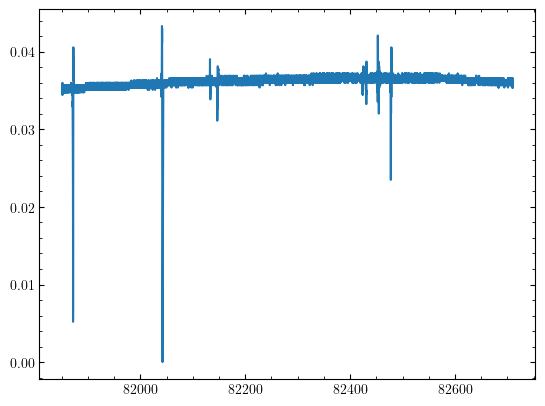

In [84]:
plt.plot(overSecs,overVolt)

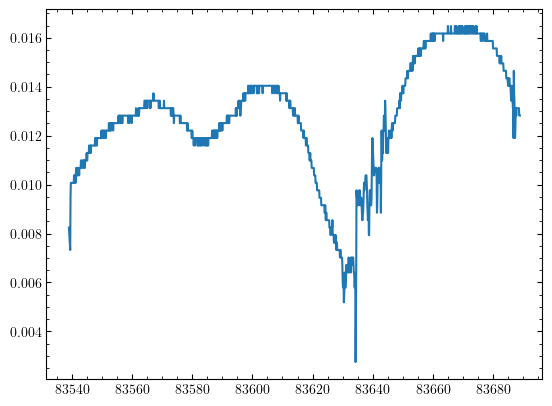

In [85]:
plt.plot(noMagSecs,noMagVolt)

In [86]:
# maybe this low frequency osc is an issue with the grounding of inputs into the amp, will check all wiring today

In [87]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

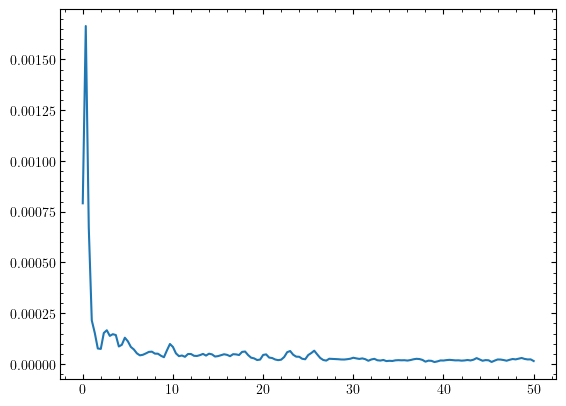

In [91]:
plt.plot(noMagF,np.sqrt(noMagPSD))
# plt.xlim(10,50)
# plt.semilogy()

In [92]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=300)

(10.0, 50.0)

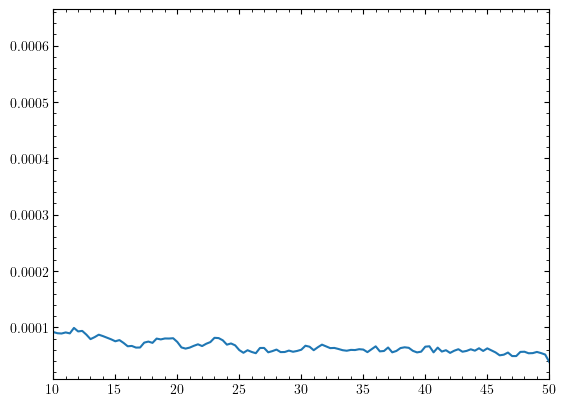

In [93]:
plt.plot(overF,np.sqrt(overPSD))
plt.xlim(10,50)
# plt.ylim(1e-10,1e-8)
# plt.semilogy()

Text(0, 0.5, '$V/\\sqrt{Hz}$')

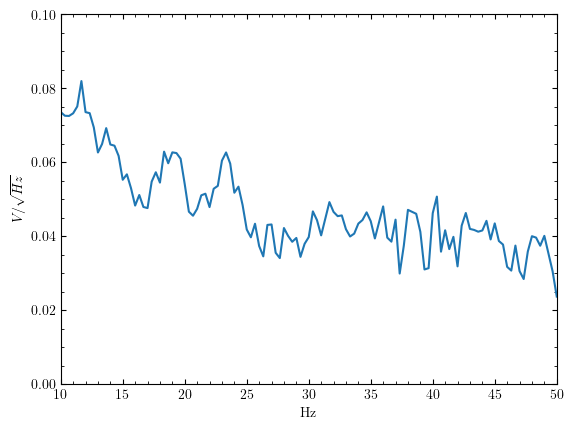

In [61]:
plt.plot(overF,1000*(np.sqrt(overPSD)-np.sqrt(noMagPSD)))
plt.xlim(10,50)
plt.ylim(0,0.1)
plt.xlabel('Hz')
plt.ylabel(r'$V/\sqrt{Hz}$')